In [1]:
!pip install kneed

In [2]:
# Importing the libraries
import numpy as np
import pandas as pd
import datetime as dt
import seaborn as sns
import math
from sklearn import preprocessing
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from kneed import KneeLocator
%matplotlib inline
import warnings

In [3]:
#Load the dataset
retail = pd.read_csv(r"C:\OnlineRetail.csv", encoding = 'ISO-8859-1')

In [4]:
#checking top 5 rows of dataset
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,1/12/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,1/12/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,1/12/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,1/12/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,1/12/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
#checking bottom 5 rows of dataset
retail.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,9/12/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,9/12/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,9/12/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,9/12/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,9/12/2011 12:50,4.95,12680.0,France


In [6]:
#checking shape of dataset
retail.shape

(541909, 8)

In [7]:
retail.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [8]:
#basic information of dataset
retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [9]:
#columns of dataset
retail.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [10]:
#Data cleaning /Data Preparation

In [11]:
#checking for null values in dataset
retail.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [12]:
#dropping null values
retail = retail.dropna(subset=['Description', 'CustomerID'])

In [13]:
#checking for missing values
retail.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [14]:
retail.duplicated().any()

True

In [15]:
retail[retail.duplicated()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,1/12/2010 11:45,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,1/12/2010 11:45,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,1/12/2010 11:45,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,1/12/2010 11:45,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,1/12/2010 11:49,2.95,17920.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,9/12/2011 11:34,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,9/12/2011 11:34,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,9/12/2011 11:34,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,9/12/2011 11:34,2.10,14446.0,United Kingdom


In [16]:
# Convert the 'InvoiceDate' column to datetime format
# Convert the 'Quantity' and 'UnitPrice' columns to numeric values
retail['InvoiceDate'] = pd.to_datetime(retail['InvoiceDate'], format='%d/%m/%Y %H:%M', errors='coerce')
retail['Quantity'] = pd.to_numeric(retail['Quantity'], errors='coerce')
retail['UnitPrice'] = pd.to_numeric(retail['UnitPrice'], errors='coerce')

In [17]:
retail.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [18]:
# Split data and time
# Extract the time part and create a new column 'InvoiceTime'
retail['InvoiceTime'] = retail['InvoiceDate'].dt.time

# Keep only the date part in 'InvoiceDate'
retail['InvoiceDate'] = retail['InvoiceDate'].dt.date

In [19]:
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceTime
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,17850.0,United Kingdom,08:26:00
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,17850.0,United Kingdom,08:26:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,17850.0,United Kingdom,08:26:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,17850.0,United Kingdom,08:26:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,17850.0,United Kingdom,08:26:00


In [20]:
# Check InvoiceNo
def contains_alphabetic(s):
    return any(char.isalpha() for char in s)

print(retail[retail['InvoiceNo'].apply(contains_alphabetic)])

       InvoiceNo StockCode                       Description  Quantity  \
141      C536379         D                          Discount        -1   
154      C536383    35004C   SET OF 3 COLOURED  FLYING DUCKS        -1   
235      C536391     22556    PLASTERS IN TIN CIRCUS PARADE        -12   
236      C536391     21984  PACK OF 12 PINK PAISLEY TISSUES        -24   
237      C536391     21983  PACK OF 12 BLUE PAISLEY TISSUES        -24   
...          ...       ...                               ...       ...   
540449   C581490     23144   ZINC T-LIGHT HOLDER STARS SMALL       -11   
541541   C581499         M                            Manual        -1   
541715   C581568     21258        VICTORIAN SEWING BOX LARGE        -5   
541716   C581569     84978  HANGING HEART JAR T-LIGHT HOLDER        -1   
541717   C581569     20979     36 PENCILS TUBE RED RETROSPOT        -5   

       InvoiceDate  UnitPrice  CustomerID         Country InvoiceTime  
141     2010-12-01      27.50     14527

In [21]:
# Filter the rows where InvoiceNo contains alphabetic characters
retail_cleaned = retail[~retail['InvoiceNo'].str.contains('[a-zA-Z]', regex=True)]

In [22]:
def contains_alphabetic(s):
    return any(char.isalpha() for char in s)

print(retail_cleaned[retail_cleaned['InvoiceNo'].apply(contains_alphabetic)])

Empty DataFrame
Columns: [InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country, InvoiceTime]
Index: []


In [23]:
retail_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    397924 non-null  object 
 1   StockCode    397924 non-null  object 
 2   Description  397924 non-null  object 
 3   Quantity     397924 non-null  int64  
 4   InvoiceDate  397924 non-null  object 
 5   UnitPrice    397924 non-null  float64
 6   CustomerID   397924 non-null  float64
 7   Country      397924 non-null  object 
 8   InvoiceTime  397924 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 30.4+ MB


In [24]:
#checking shape
retail_cleaned.shape

(397924, 9)

In [25]:
# Check negative value
print("Number of negative quantities:\n", (retail_cleaned['Quantity'] <= 0).sum())
print("Number of zero or negative prices:\n", (retail_cleaned['UnitPrice'] <= 0).sum())

Number of negative quantities:
 0
Number of zero or negative prices:
 40


In [26]:
# Remove rows with negative or zero values in Quantity and UnitPrice
retail_cleaned = retail_cleaned[(retail_cleaned['Quantity'] > 0) & (retail_cleaned['UnitPrice'] > 0.01)]

In [27]:
# Check negative value
print("Number of negative quantities:\n", (retail_cleaned['Quantity'] <= 0).sum())
print("Number of zero or negative prices:\n", (retail_cleaned['UnitPrice'] <= 0).sum())

Number of negative quantities:
 0
Number of zero or negative prices:
 0


In [28]:
# Remove outliers in 'Quantity' column
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = retail_cleaned['Quantity'].quantile(0.25)
Q3 = retail_cleaned['Quantity'].quantile(0.75)
IQR = Q3 - Q1

# Determine outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

retail_cleaned = retail_cleaned[~((retail_cleaned['Quantity'] < lower_bound) | (retail_cleaned['Quantity'] > upper_bound))]

In [29]:
# Remove outliers in 'UnitPrice' column
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = retail_cleaned['UnitPrice'].quantile(0.25)
Q3 = retail_cleaned['UnitPrice'].quantile(0.75)
IQR = Q3 - Q1

# Determine outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

retail_cleaned = retail_cleaned[~((retail_cleaned['UnitPrice'] < lower_bound) | (retail_cleaned['UnitPrice'] > upper_bound))]

In [30]:
retail_cleaned.describe()

,Quantity,UnitPrice,CustomerID
count,338147.000000,338147.000000,338147.000000
mean,7.476994,2.192043,15325.973639
std,6.770798,1.544761,1710.735845
min,1.000000,0.060000,12347.000000
25%,2.000000,1.250000,13994.000000
50%,6.000000,1.650000,15245.000000
75%,12.000000,2.950000,16818.000000
max,27.000000,7.500000,18287.000000


In [31]:
# Calculate total price for each row
retail_cleaned['TotalPrice'] = retail_cleaned['Quantity'] * retail_cleaned['UnitPrice']

In [32]:
# Remove outliers in 'TotalPrice' column
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = retail_cleaned['TotalPrice'].quantile(0.25)
Q3 = retail_cleaned['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1

# Determine outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

retail_cleaned = retail_cleaned[~((retail_cleaned['TotalPrice'] < lower_bound) | (retail_cleaned['TotalPrice'] > upper_bound))]

In [33]:
# Display cleaned data
retail_cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceTime,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,17850.0,United Kingdom,08:26:00,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,17850.0,United Kingdom,08:26:00,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,17850.0,United Kingdom,08:26:00,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,17850.0,United Kingdom,08:26:00,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,17850.0,United Kingdom,08:26:00,20.34


In [34]:
retail_cleaned.describe()

,Quantity,UnitPrice,CustomerID,TotalPrice
count,324712.000000,324712.000000,324712.000000,324712.000000
mean,7.071044,2.123786,15338.954326,10.854344
std,6.486074,1.500048,1709.320269,8.235657
min,1.000000,0.060000,12347.000000,0.060000
25%,2.000000,0.950000,14019.000000,3.750000
50%,5.000000,1.650000,15275.000000,9.900000
75%,12.000000,2.950000,16842.000000,16.500000
max,27.000000,7.500000,18287.000000,37.700000


In [35]:
retail_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 324712 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    324712 non-null  object 
 1   StockCode    324712 non-null  object 
 2   Description  324712 non-null  object 
 3   Quantity     324712 non-null  int64  
 4   InvoiceDate  324712 non-null  object 
 5   UnitPrice    324712 non-null  float64
 6   CustomerID   324712 non-null  float64
 7   Country      324712 non-null  object 
 8   InvoiceTime  324712 non-null  object 
 9   TotalPrice   324712 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 27.3+ MB


In [36]:
retail_cleaned.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
InvoiceTime    0
TotalPrice     0
dtype: int64

In [37]:
retail_cleaned = retail_cleaned.reset_index(drop=True)

In [38]:
# Display the first few rows
print("Dataframe with Purchases:")
print(retail_cleaned.head())

Dataframe with Purchases:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

  InvoiceDate  UnitPrice  CustomerID         Country InvoiceTime  TotalPrice  
0  2010-12-01       2.55     17850.0  United Kingdom    08:26:00       15.30  
1  2010-12-01       3.39     17850.0  United Kingdom    08:26:00       20.34  
2  2010-12-01       2.75     17850.0  United Kingdom    08:26:00       22.00  
3  2010-12-01       3.39     17850.0  United Kingdom    08:26:00       20.34  
4  2010-12-01       3.39     17850.0  United Kingdom    08:26:00       20.34  


In [39]:
#Recency = Latest Date - Last Inovice Data, Frequency = count of invoice no. of transaction(s), Monetary = Sum of Total 
#Amount for each customer

retail_cleaned = retail_cleaned.head(80000)

retail_cleaned['InvoiceDate'] = pd.to_datetime(retail_cleaned['InvoiceDate'])
Latest_Date = dt.datetime(2011,12,10)

# Calculate RFM metrics from the purchases data
rfm = retail_cleaned.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (Latest_Date - x.max()).days, 
    'InvoiceNo': lambda x: len(x), 
    'TotalPrice': lambda x: x.sum()
}).reset_index()

#Convert Invoice Date into type int
rfm['InvoiceDate'] = rfm['InvoiceDate'].astype(int)

#Rename column names to Recency, Frequency and Monetary
rfm.rename(columns={'InvoiceDate': 'Recency', 
                         'InvoiceNo': 'Frequency', 
                         'TotalPrice': 'Monetary'}, inplace=True)

# Remove any negative or zero values in Frequency and Monetary for stability in log transformation
rfm = rfm[(rfm['Frequency'] > 0) & (rfm['Monetary'] > 0)]

In [40]:
#Descriptive Statistics (Recency)
rfm.Recency.describe()

count    2053.000000
mean      295.923527
std        38.346267
min       247.000000
25%       263.000000
50%       285.000000
75%       320.000000
max       374.000000
Name: Recency, dtype: float64

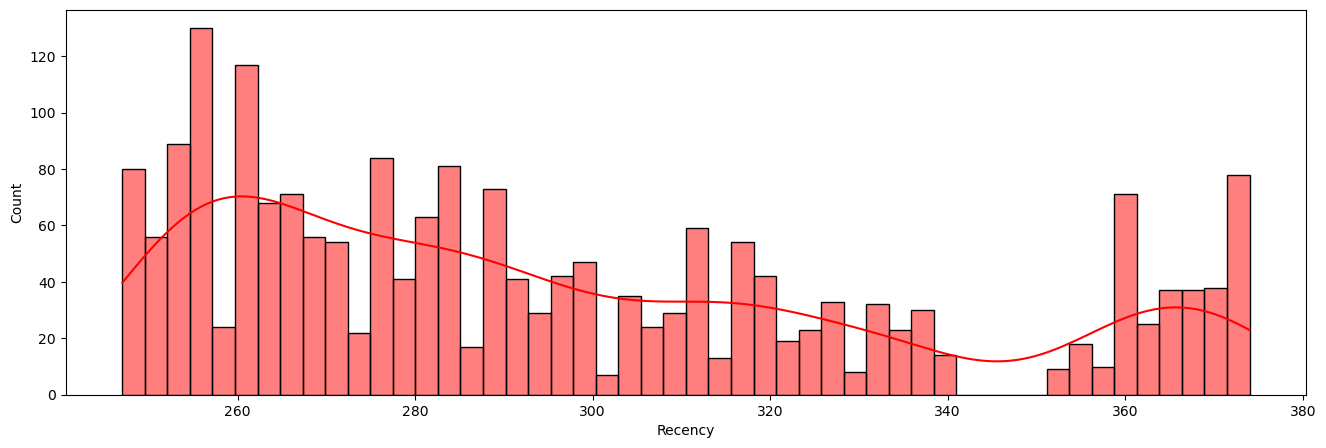

In [41]:
#Recency distribution plot （data exploration）
x = rfm['Recency']
plt.figure(figsize=(16,5))
sns.histplot(x,color='red', bins=50, kde=True);

In [42]:
#Descriptive Statistics (Frequency)
rfm.Frequency.describe()

count    2053.000000
mean       38.967365
std        63.178122
min         1.000000
25%        10.000000
50%        21.000000
75%        45.000000
max      1051.000000
Name: Frequency, dtype: float64

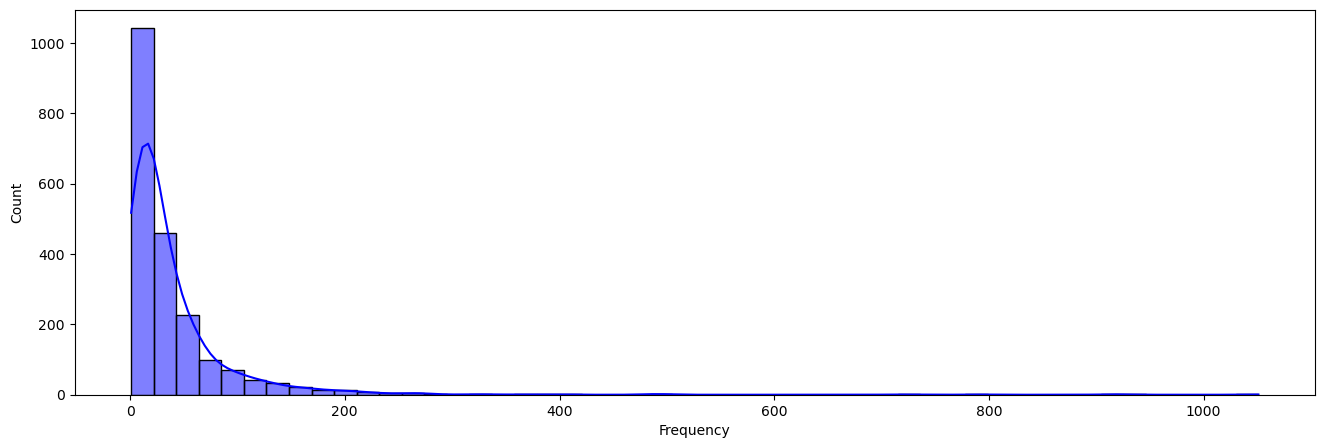

In [43]:
#Frequency distribution plot, taking observations which have frequency less than 1000 (data exploration）
x = rfm['Frequency']
plt.figure(figsize=(16,5))
sns.histplot(x,color='blue', bins=50, kde=True);

In [44]:
#Descriptive Statistics (Monetary)
rfm.Monetary.describe()

count     2053.000000
mean       428.092148
std        598.977722
min          0.850000
25%        134.400000
50%        266.200000
75%        506.930000
max      13136.180000
Name: Monetary, dtype: float64

<Axes: xlabel='Monetary', ylabel='Count'>

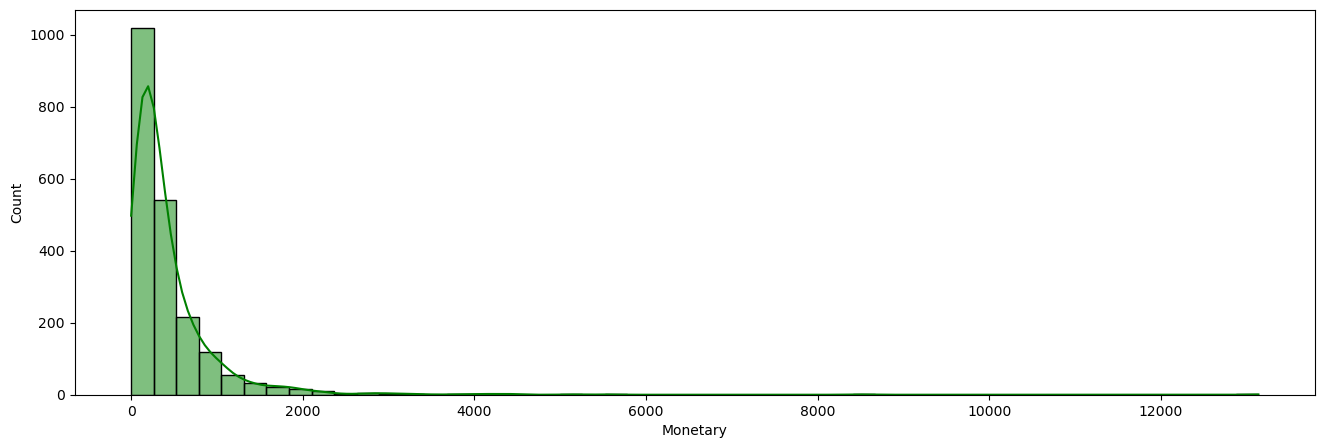

In [45]:
#Monateray distribution plot, taking observations which have monetary value less than 10000
x = rfm['Monetary']
plt.figure(figsize=(16,5))
sns.histplot(x,color='green', bins=50, kde=True)

In [46]:
#Split into four segments using quantiles
quantiles = rfm.quantile(q=[0.25,0.5,0.75])
quantiles = quantiles.to_dict()

In [47]:
quantiles

{'CustomerID': {0.25: 13819.0, 0.5: 15249.0, 0.75: 16778.0},
 'Recency': {0.25: 263.0, 0.5: 285.0, 0.75: 320.0},
 'Frequency': {0.25: 10.0, 0.5: 21.0, 0.75: 45.0},
 'Monetary': {0.25: 134.4, 0.5: 266.2, 0.75: 506.92999999999995}}

In [48]:
#Functions to create R, F and M segments according to quantiles for recency low score is important and for frequency and monetory maximum is important.
#so keeping this in mind we are creating two function to create scores
def RScoring(x,p,d):
    if x <= d[p][0.25]:
        return 1
    elif x <= d[p][0.50]:
        return 2
    elif x <= d[p][0.75]: 
        return 3
    else:
        return 4
    
def FnMScoring(x,p,d):
    if x <= d[p][0.25]:
        return 4
    elif x <= d[p][0.50]:
        return 3
    elif x <= d[p][0.75]: 
        return 2
    else:
        return 1

In [49]:
#Calculate Add R, F and M segment value columns in the existing dataset to show R, F and M segment values
rfm['R'] = rfm['Recency'].apply(RScoring, args=('Recency',quantiles,))
rfm['F'] = rfm['Frequency'].apply(FnMScoring, args=('Frequency',quantiles,))
rfm['M'] = rfm['Monetary'].apply(FnMScoring, args=('Monetary',quantiles,))
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R,F,M
0,12347.0,247,75,1247.43,1,1,1
1,12348.0,249,6,90.20,1,4,4
2,12350.0,311,16,294.40,3,3,2
3,12352.0,263,30,539.41,1,2,1
4,12356.0,326,9,223.20,4,4,3


In [50]:
#Calculate and Add RFMGroup value column showing combined concatenated score of RFM
rfm['RFMGroup'] = rfm.R.map(str) + rfm.F.map(str) + rfm.M.map(str)

#Calculate and Add RFMScore value column showing total sum of RFMGroup values
rfm['RFMScore'] = rfm[['R', 'F', 'M']].sum(axis = 1)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R,F,M,RFMGroup,RFMScore
0,12347.0,247,75,1247.43,1,1,1,111,3
1,12348.0,249,6,90.20,1,4,4,144,9
2,12350.0,311,16,294.40,3,3,2,332,8
3,12352.0,263,30,539.41,1,2,1,121,4
4,12356.0,326,9,223.20,4,4,3,443,11


In [51]:
#Handling negative and zero values so as to handle infinite numbers during log transformation
def handle_neg_n_zero(num):
    if num <= 0:
        return 1
    else:
        return num
#Applying handle_neg_n_zero function to Recency and Monetary columns 
rfm['Recency'] = [handle_neg_n_zero(x) for x in rfm.Recency]
rfm['Monetary'] = [handle_neg_n_zero(x) for x in rfm.Monetary]

#Performing Log transformation to bring data into normal or near normal distribution
Log_Tfd_Data = rfm[['Recency', 'Frequency', 'Monetary']].apply(np.log, axis = 1).round(3)

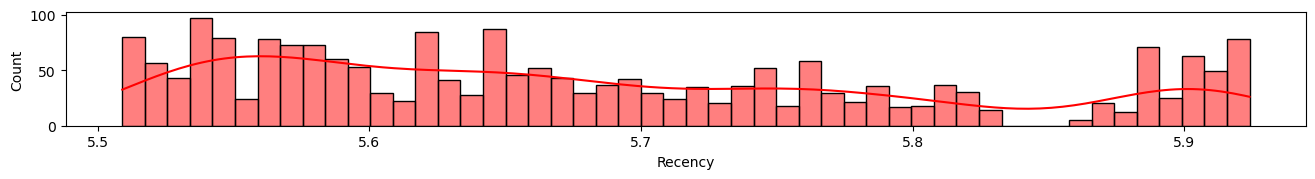

In [52]:
#Data distribution after data normalization for Recency
Recency_Plot = Log_Tfd_Data['Recency']
plt.figure(figsize=(16,5))
plt.subplot(3, 1, 1)
sns.histplot(Recency_Plot,color='red', bins=50, kde=True);

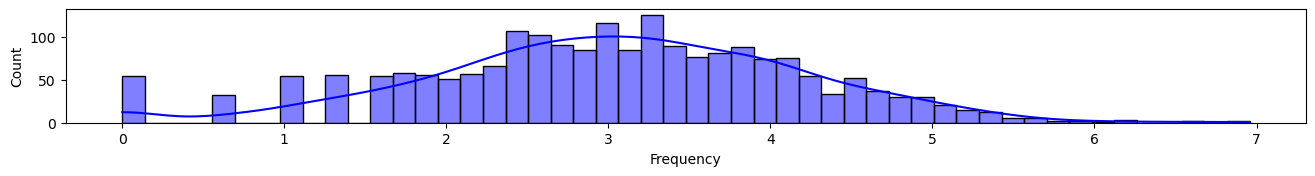

In [53]:
#Data distribution after data normalization for Frequency
Frequency_Plot = Log_Tfd_Data.query('Frequency < 1000')['Frequency']
plt.figure(figsize=(16,5))
plt.subplot(3, 1, 2)
sns.histplot(Frequency_Plot,color='blue', bins=50, kde=True);

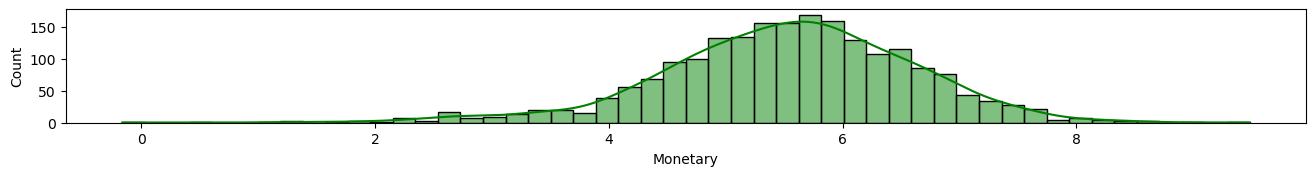

In [54]:
#Data distribution after data normalization for Monetary
Monetary_Plot = Log_Tfd_Data.query('Monetary < 10000')['Monetary']
plt.figure(figsize=(16,5))
plt.subplot(3, 1, 3)
sns.histplot(Monetary_Plot,color='green', bins=50, kde=True);

In [55]:
rfm['Recency_log'] = rfm['Recency'].apply(math.log)
rfm['Frequency_log'] = rfm['Frequency'].apply(math.log)
rfm['Monetary_log'] = rfm['Monetary'].apply(math.log)

In [56]:
# Hyperparameters for RFM Analysis
quantile_range = 5  # Number of segments for R, F, and M (e.g., 5 for quintiles)
recency_labels = [5, 4, 3, 2, 1]  # Higher score for more recent purchases
frequency_labels = [1, 2, 3, 4, 5]  # Higher score for more frequent purchases
monetary_labels = [1, 2, 3, 4, 5]   # Higher score for higher spending

In [57]:
# Assign R, F, and M scores using quantiles
rfm['R_score'] = pd.qcut(rfm['Recency'], q=quantile_range, labels=recency_labels)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=quantile_range, labels=frequency_labels)
rfm['M_score'] = pd.qcut(rfm['Monetary'], q=quantile_range, labels=monetary_labels)

In [58]:
# Combine RFM scores into a single score
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

In [59]:
#Customer Segmentation Based on RFM Scores
# Map RFM Scores to customer segments
segment_map = {
    r'[1-2][1-2]': 'Lost',
    r'[1-2][3-4]': 'At Risk',
    r'[1-2]5': 'Can’t Lose Them',
    r'3[1-2]': 'About to Sleep',
    r'33': 'Need Attention',
    r'[3-4][4-5]': 'Loyal',
    r'41': 'Promising',
    r'51': 'New Customers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]': 'Champions'
}

# Create a 'Segment' column based on RFM_Score using the mapping
rfm['Segment'] = rfm['RFM_Score'].replace(segment_map, regex=True)


In [60]:
# Display the RFM analysis result
print(rfm.head())

# Summary statistics of different customer segments
segment_summary = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

print("\nSegment Summary:")
print(segment_summary)

   CustomerID  Recency  Frequency  Monetary  R  F  M RFMGroup  RFMScore  \
0     12347.0      247         75   1247.43  1  1  1      111         3   
1     12348.0      249          6     90.20  1  4  4      144         9   
2     12350.0      311         16    294.40  3  3  2      332         8   
3     12352.0      263         30    539.41  1  2  1      121         4   
4     12356.0      326          9    223.20  4  4  3      443        11   

   Recency_log  Frequency_log  Monetary_log R_score F_score M_score RFM_Score  \
0     5.509388       4.317488      7.128841       5       5       5       555   
1     5.517453       1.791759      4.502029       5       1       1       511   
2     5.739793       2.772589      5.684939       2       2       3       223   
3     5.572154       3.401197      6.290476       4       4       4       444   
4     5.786897       2.197225      5.408068       2       2       3       223   

      Segment  
0  Champions5  
1       5Lost  
2       Lost3 

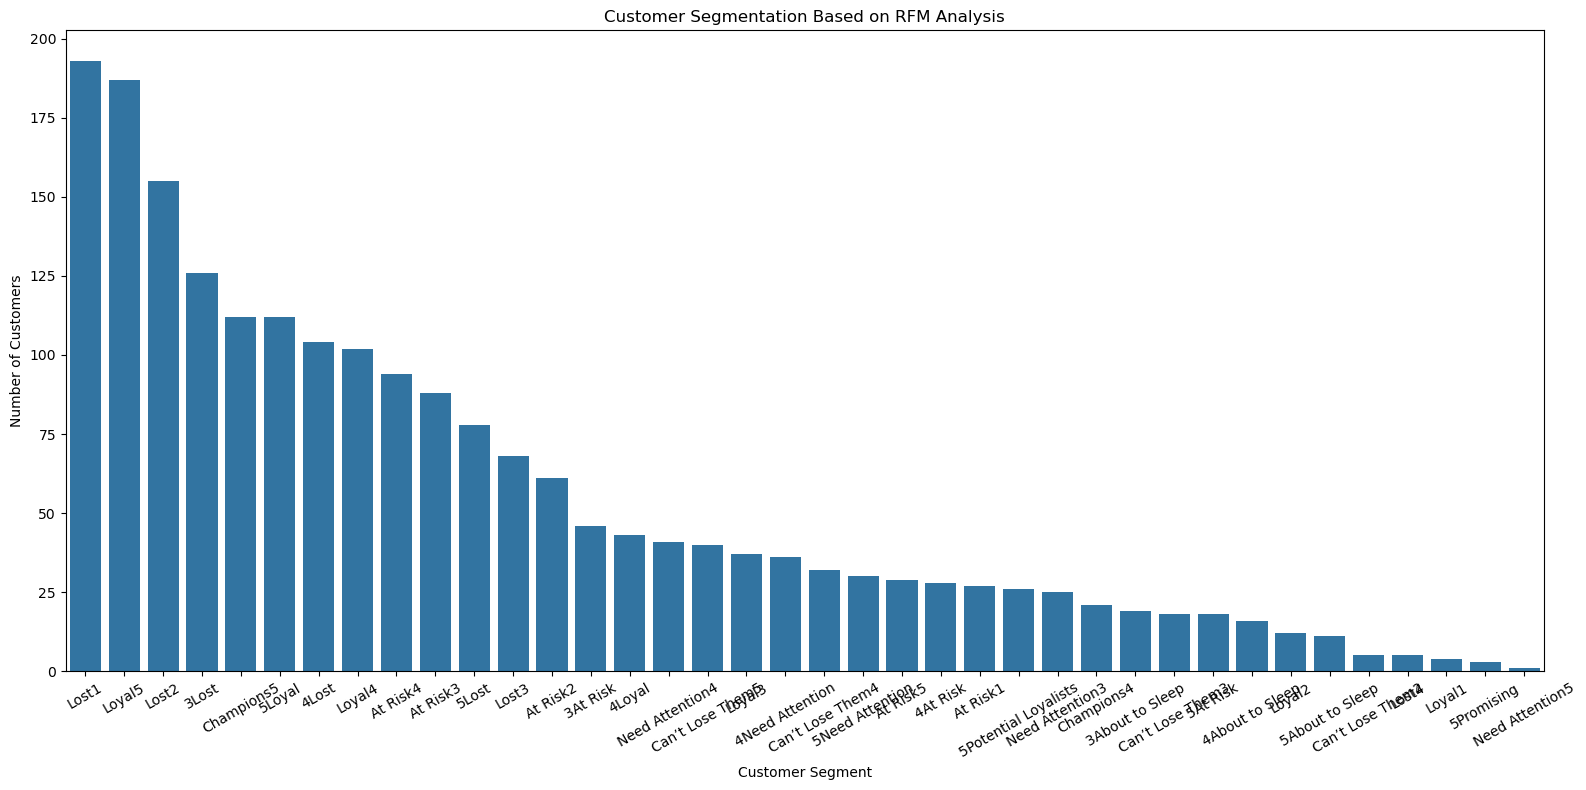

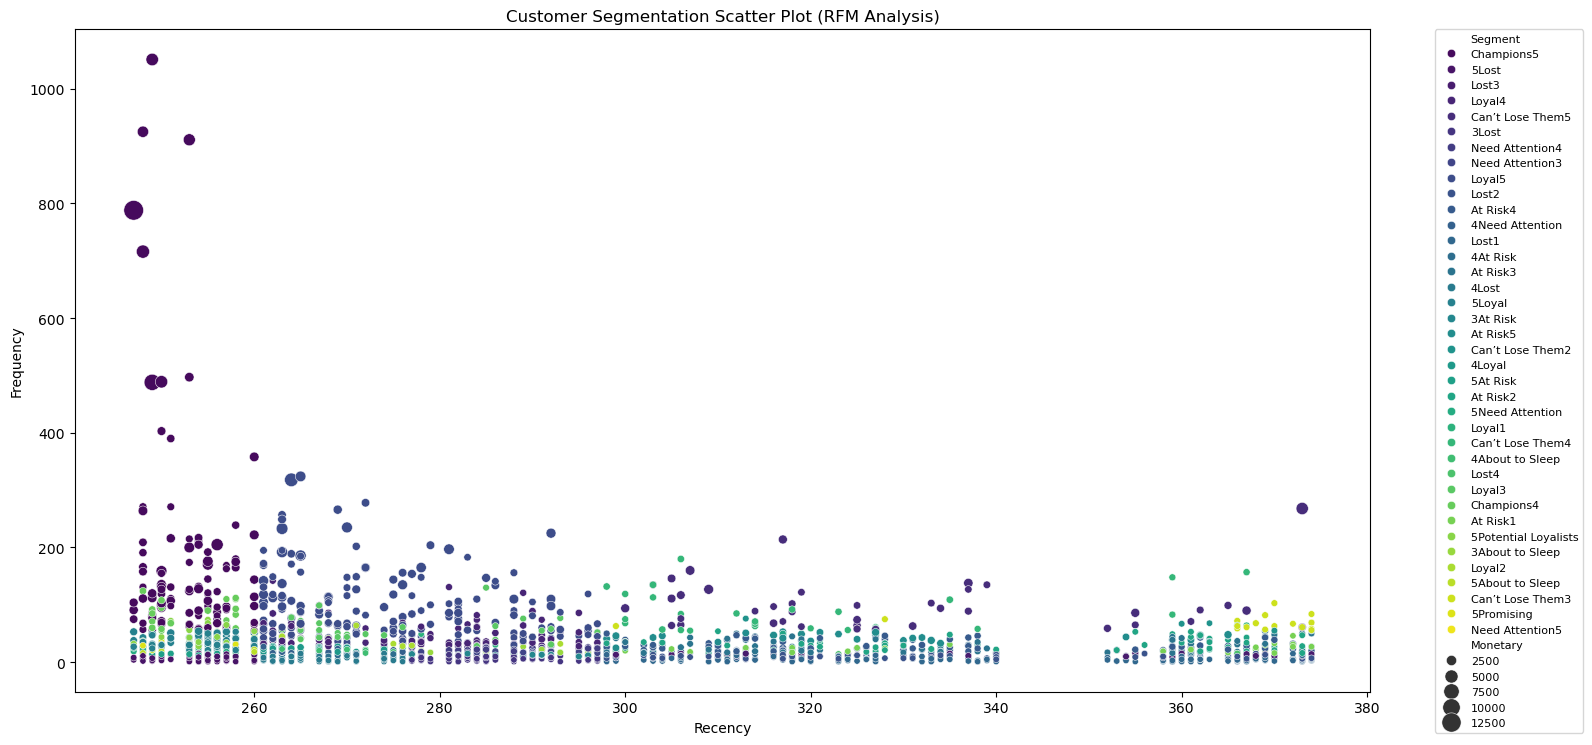

In [61]:
# Visualization: Plot customer segments
plt.figure(figsize=(16, 8))
sns.countplot(x='Segment', data=rfm, order=rfm['Segment'].value_counts().index)
plt.title('Customer Segmentation Based on RFM Analysis')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30, fontsize=10)
plt.tight_layout()
plt.show()

# Visualization: Scatter plot of RFM scores
plt.figure(figsize=(16, 8))
sns.scatterplot(x='Recency', y='Frequency', size='Monetary', hue='Segment', data=rfm, palette="viridis", sizes=(20, 200))
plt.title('Customer Segmentation Scatter Plot (RFM Analysis)')
plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize=8)
plt.tight_layout()
plt.show()

# Explanation:
# - The count plot provides a visual representation of the number of customers in each segment.
# - The scatter plot visualizes the relationship between Recency, Frequency, and Monetary values, color-coded by customer segment.

In [62]:
#silhoutte score
features_rec_mon=['Recency_log','Monetary_log']
X_features_rec_mon=rfm[features_rec_mon].values
scaler_rec_mon=preprocessing.StandardScaler()
X_rec_mon=scaler_rec_mon.fit_transform(X_features_rec_mon)
X=X_rec_mon
range_n_clusters = [2,3,4,5,6,7,8,9,10,11,12,13,14,15]
for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters)
    preds = clusterer.fit_predict(X)
    centers = clusterer.cluster_centers_

    score = silhouette_score(X, preds)
    print("For n_clusters = {}, silhouette score is {}".format(n_clusters, score))

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


For n_clusters = 2, silhouette score is 0.4104398997065926


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


For n_clusters = 3, silhouette score is 0.4033031776166304


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


...

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


For n_clusters = 13, silhouette score is 0.35850191676651705


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


For n_clusters = 14, silhouette score is 0.37224314065720254
For n_clusters = 15, silhouette score is 0.3665175498829459


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows wi

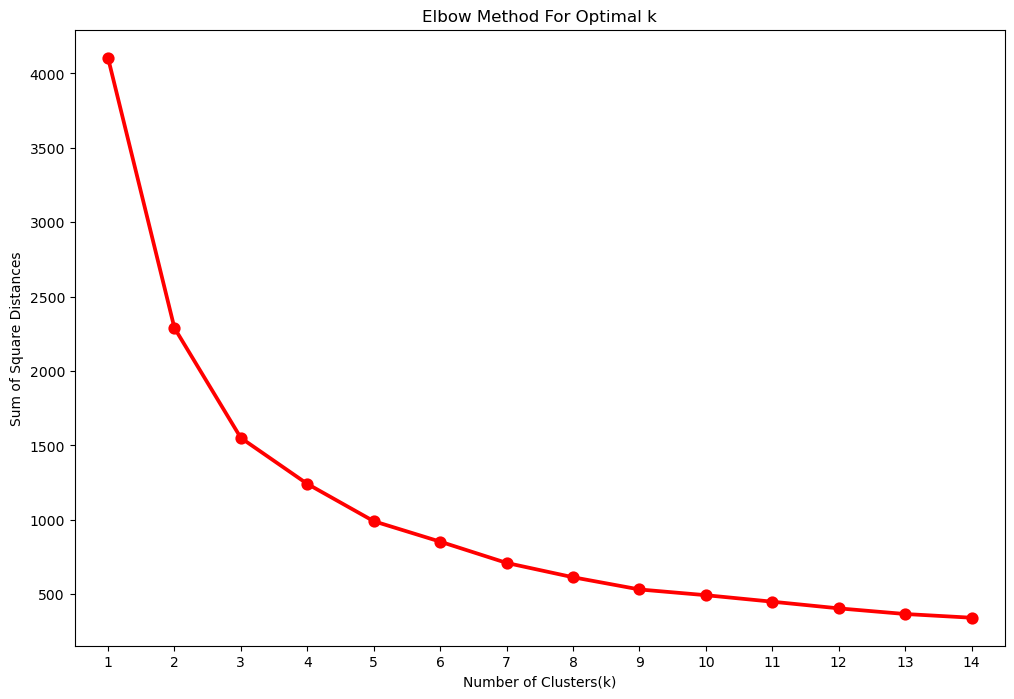

In [63]:
#applying elbow method
features_rec_mon=['Recency_log','Monetary_log']
X_features_rec_mon=rfm[features_rec_mon].values
scaler_rec_mon=preprocessing.StandardScaler()
X_rec_mon=scaler_rec_mon.fit_transform(X_features_rec_mon)
X=X_rec_mon

sum_of_sq_dist = {}
for k in range(1,15):
    km = KMeans(n_clusters= k, init= 'k-means++', max_iter= 1000)
    km = km.fit(X)
    sum_of_sq_dist[k] = km.inertia_
    
#Plot the graph for the sum of square distance values and Number of Clusters
plt.figure(figsize=(12,8))
sns.pointplot(x = list(sum_of_sq_dist.keys()), y = list(sum_of_sq_dist.values()),color='r')
plt.xlabel('Number of Clusters(k)')
plt.ylabel('Sum of Square Distances')
plt.title('Elbow Method For Optimal k')
plt.show()

In [64]:
kmeans = KMeans(n_clusters=2)
kmeans.fit(X)
y_kmeans= kmeans.predict(X)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


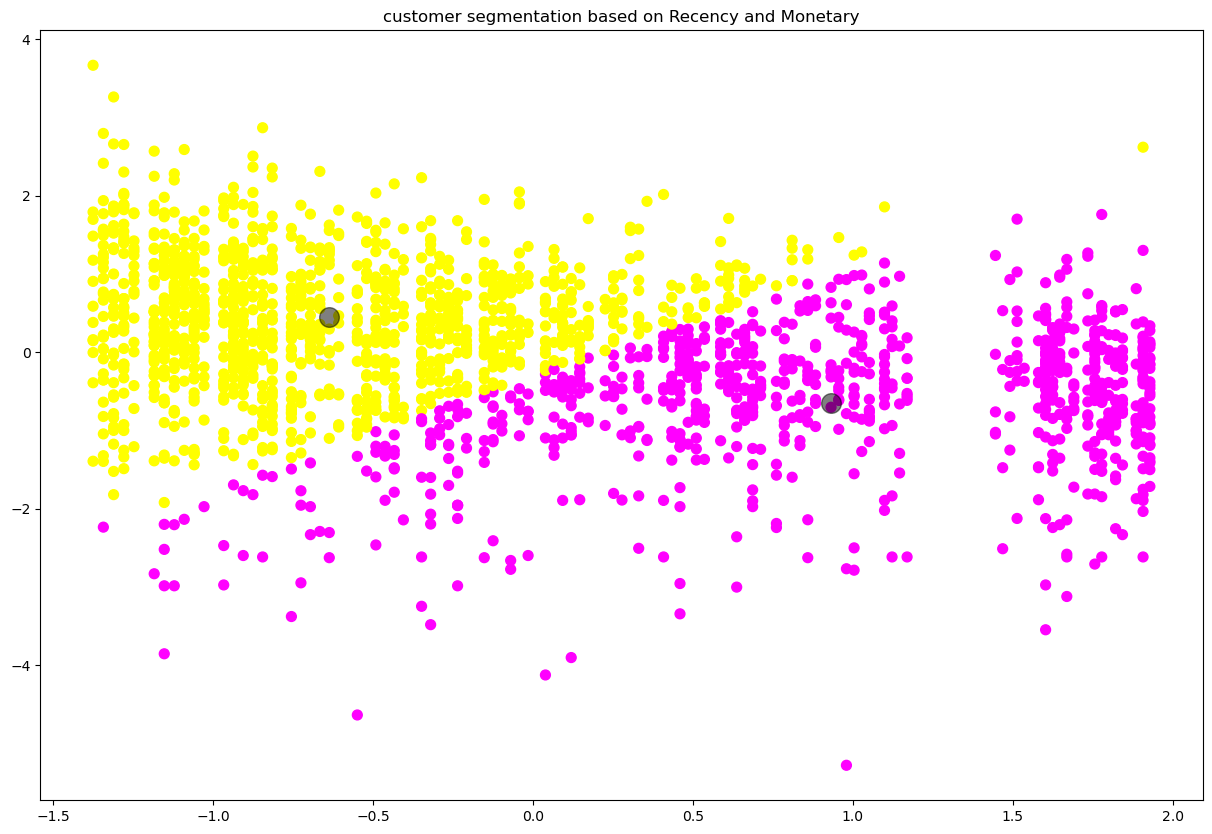

In [65]:
plt.figure(figsize=(15,10))
plt.title('customer segmentation based on Recency and Monetary')
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='spring_r')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);

In [66]:
#silhouetee score
features_fre_mon=['Frequency_log','Monetary_log']
X_features_fre_mon=rfm[features_fre_mon].values
scaler_fre_mon=preprocessing.StandardScaler()
X_fre_mon=scaler_fre_mon.fit_transform(X_features_fre_mon)
X=X_fre_mon
range_n_clusters = [2,3,4,5,6,7,8,9,10,11,12,13,14,15]
for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters)
    preds = clusterer.fit_predict(X)
    centers = clusterer.cluster_centers_

    score = silhouette_score(X, preds)
    print("For n_clusters = {}, silhouette score is {}".format(n_clusters, score))

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


For n_clusters = 2, silhouette score is 0.4796091680038971


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


For n_clusters = 3, silhouette score is 0.45274392895767634


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


...

For n_clusters = 13, silhouette score is 0.39452193815296926


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


For n_clusters = 14, silhouette score is 0.40077987273933474


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


For n_clusters = 15, silhouette score is 0.39342001881753474


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows wi

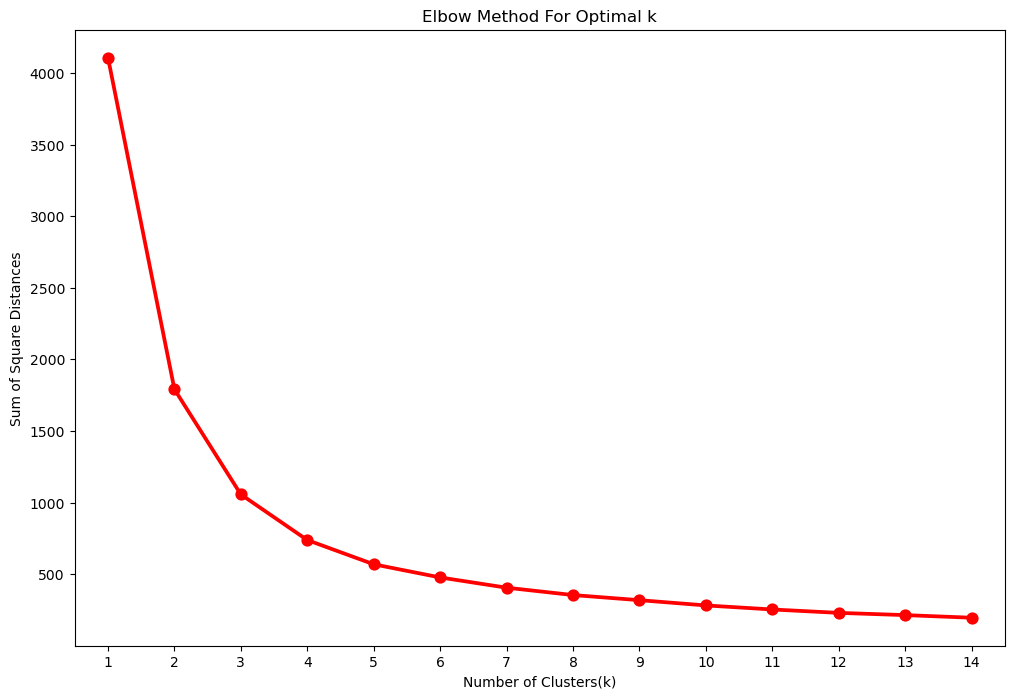

In [67]:
#applying elbow method
sum_of_sq_dist = {}
for k in range(1,15):
    km = KMeans(n_clusters= k, init= 'k-means++', max_iter= 1000)
    km = km.fit(X)
    sum_of_sq_dist[k] = km.inertia_
    
#Plot the graph for the sum of square distance values and Number of Clusters
plt.figure(figsize=(12,8))
sns.pointplot(x = list(sum_of_sq_dist.keys()), y = list(sum_of_sq_dist.values()),color='r')
plt.xlabel('Number of Clusters(k)')
plt.ylabel('Sum of Square Distances')
plt.title('Elbow Method For Optimal k')
plt.show()

In [68]:
kmeans = KMeans(n_clusters=2)
kmeans.fit(X)
y_kmeans= kmeans.predict(X)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


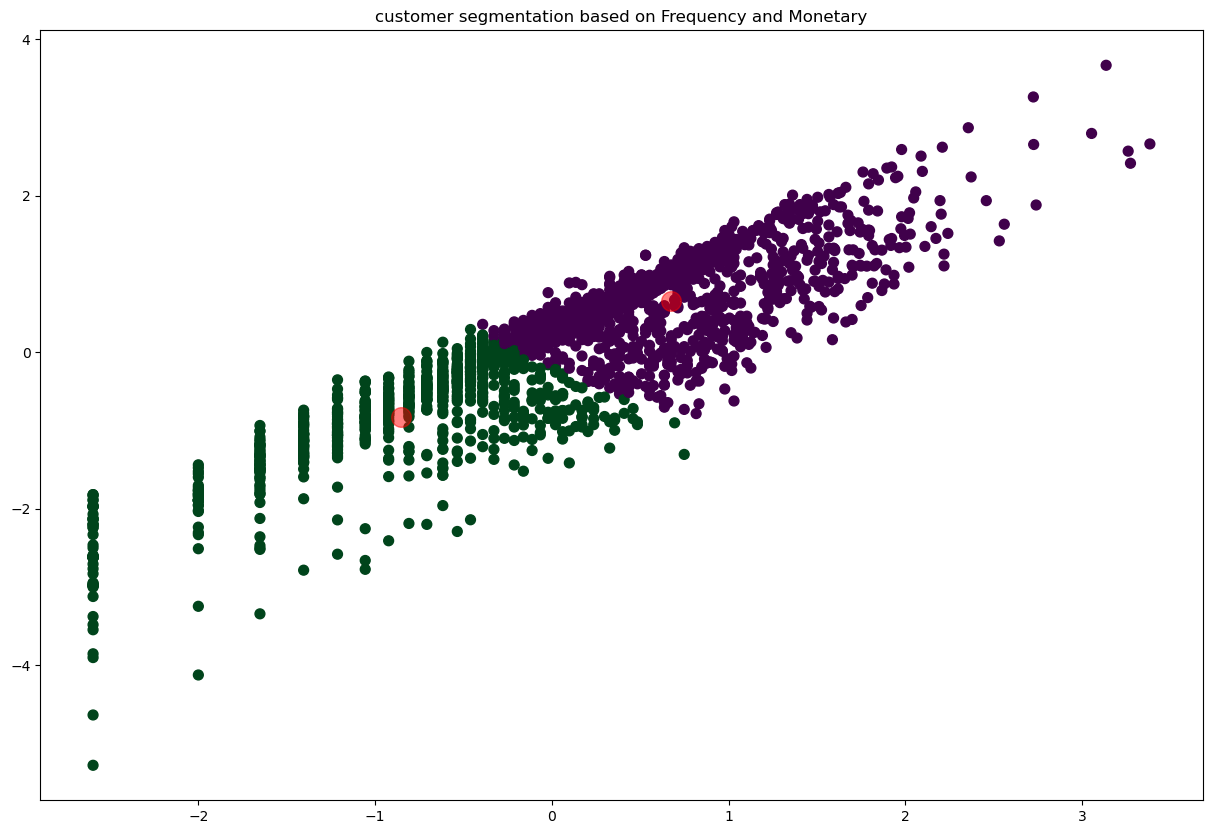

In [69]:
#plotting graph based on frequency and monetary
plt.figure(figsize=(15,10))
plt.title('customer segmentation based on Frequency and Monetary')
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='PRGn')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5);

In [70]:
#scaling features
feature_vector=['Recency_log','Frequency_log','Monetary_log']
X_features=rfm[feature_vector].values
scaler=preprocessing.StandardScaler()
X=scaler.fit_transform(X_features)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


For n_clusters = 2 The average silhouette_score is : 0.36390183334997717


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


For n_clusters = 3 The average silhouette_score is : 0.3644792271827361


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


...

For n_clusters = 8 The average silhouette_score is : 0.3256772028332129


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


For n_clusters = 9 The average silhouette_score is : 0.29829518612890893


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


For n_clusters = 10 The average silhouette_score is : 0.2992085797004746


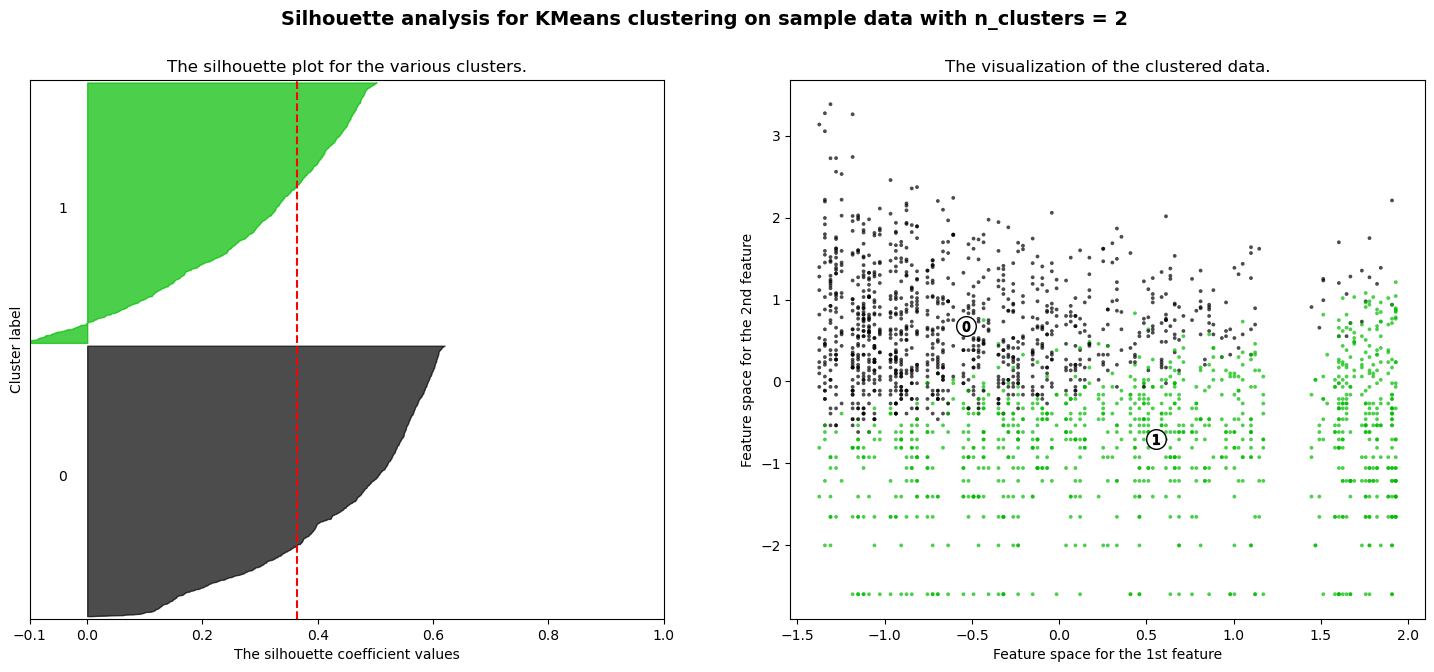

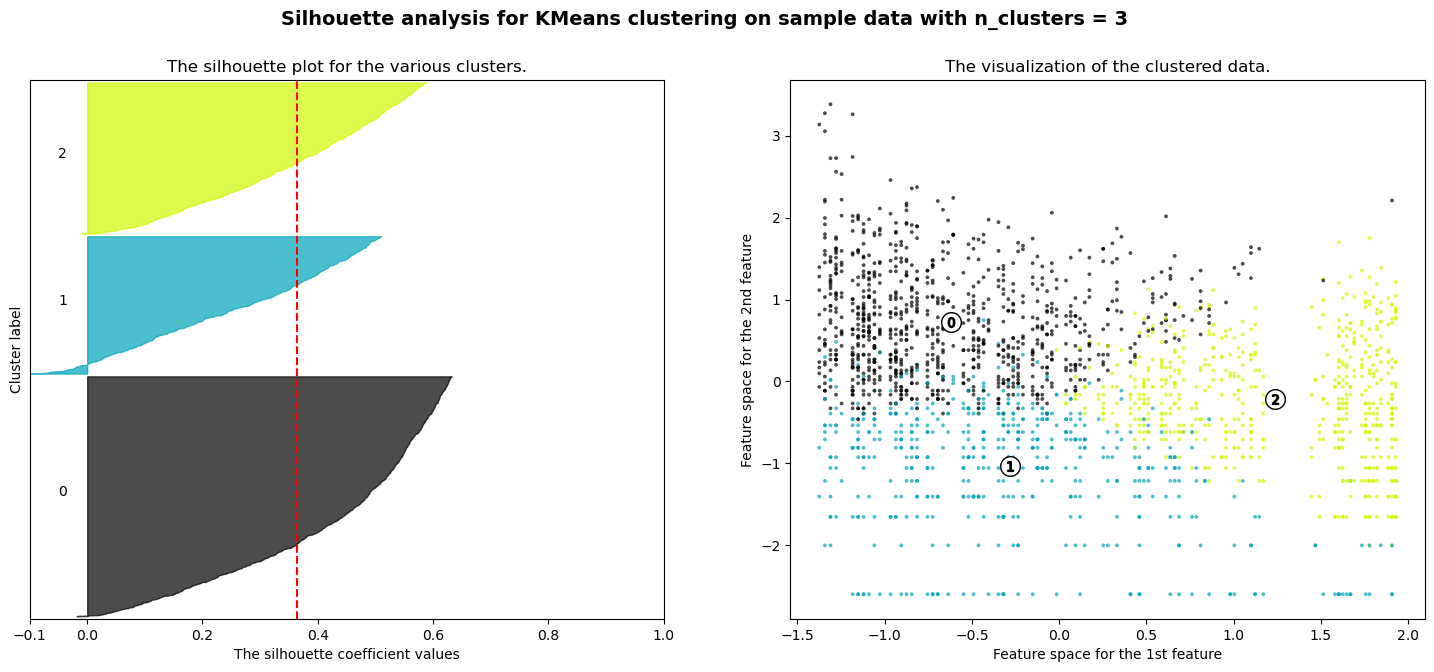

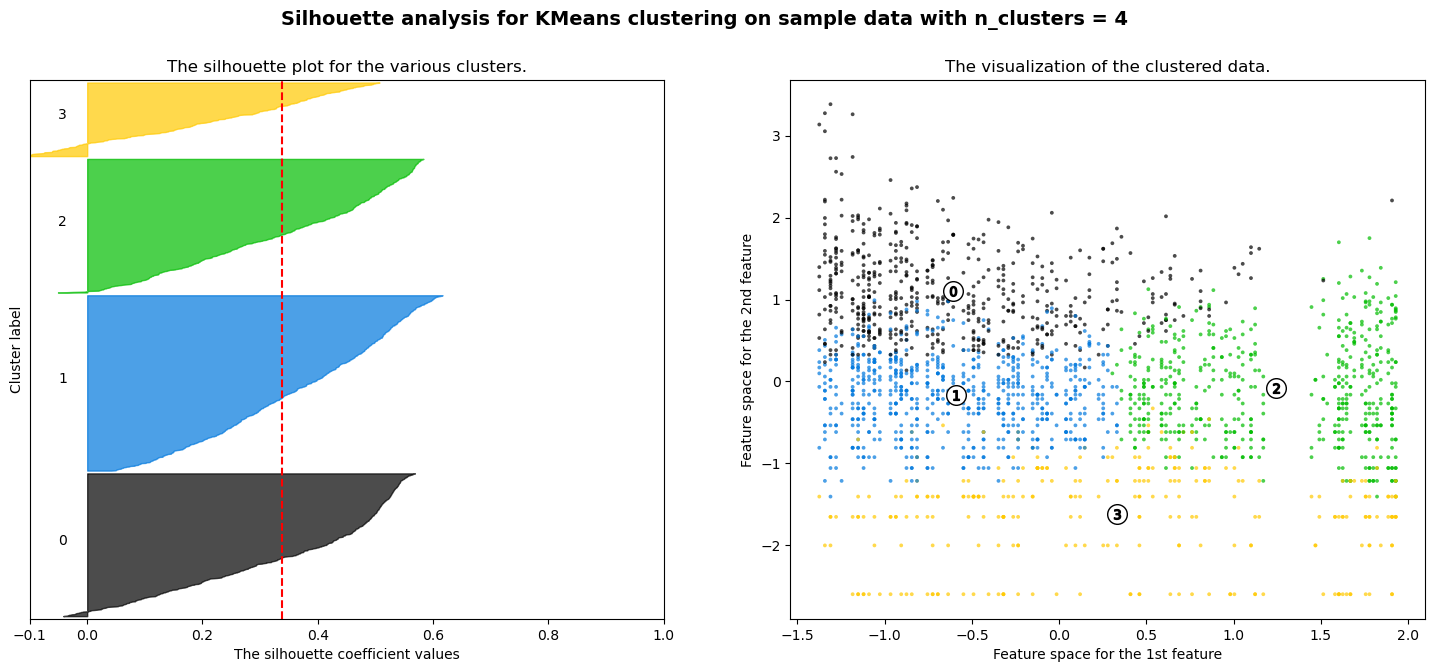

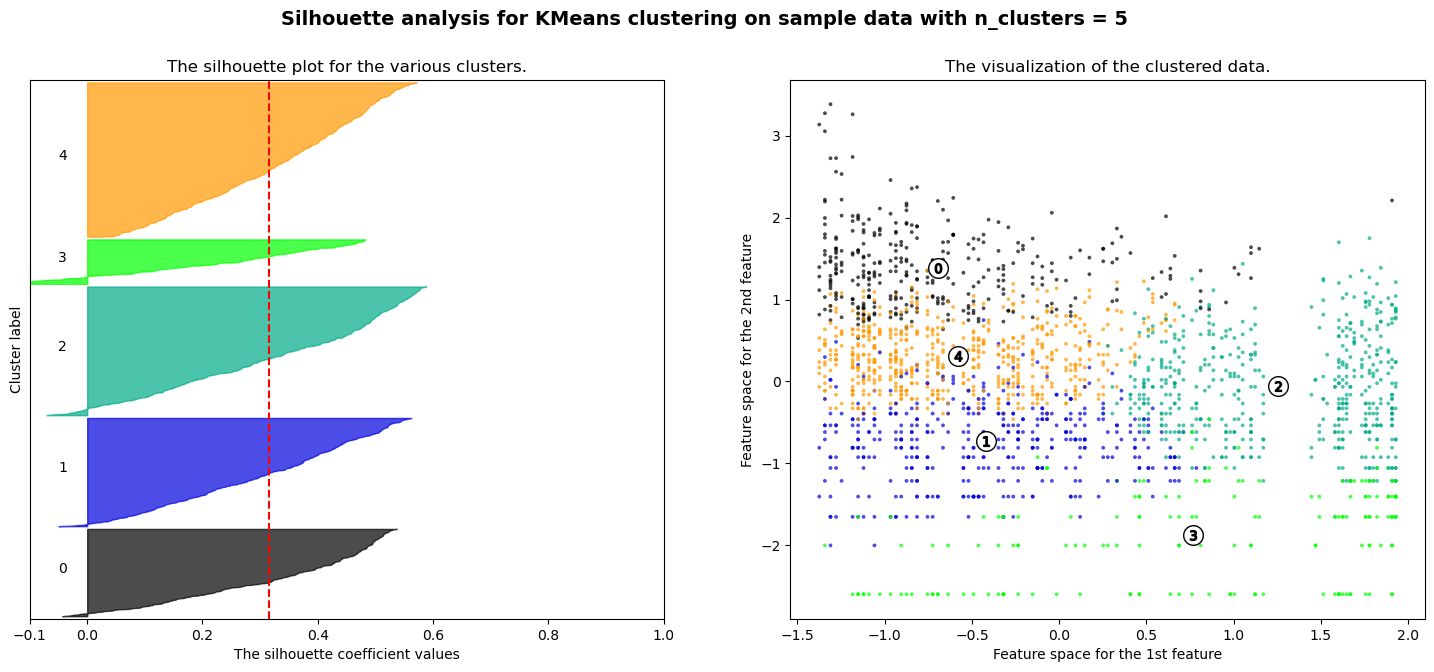

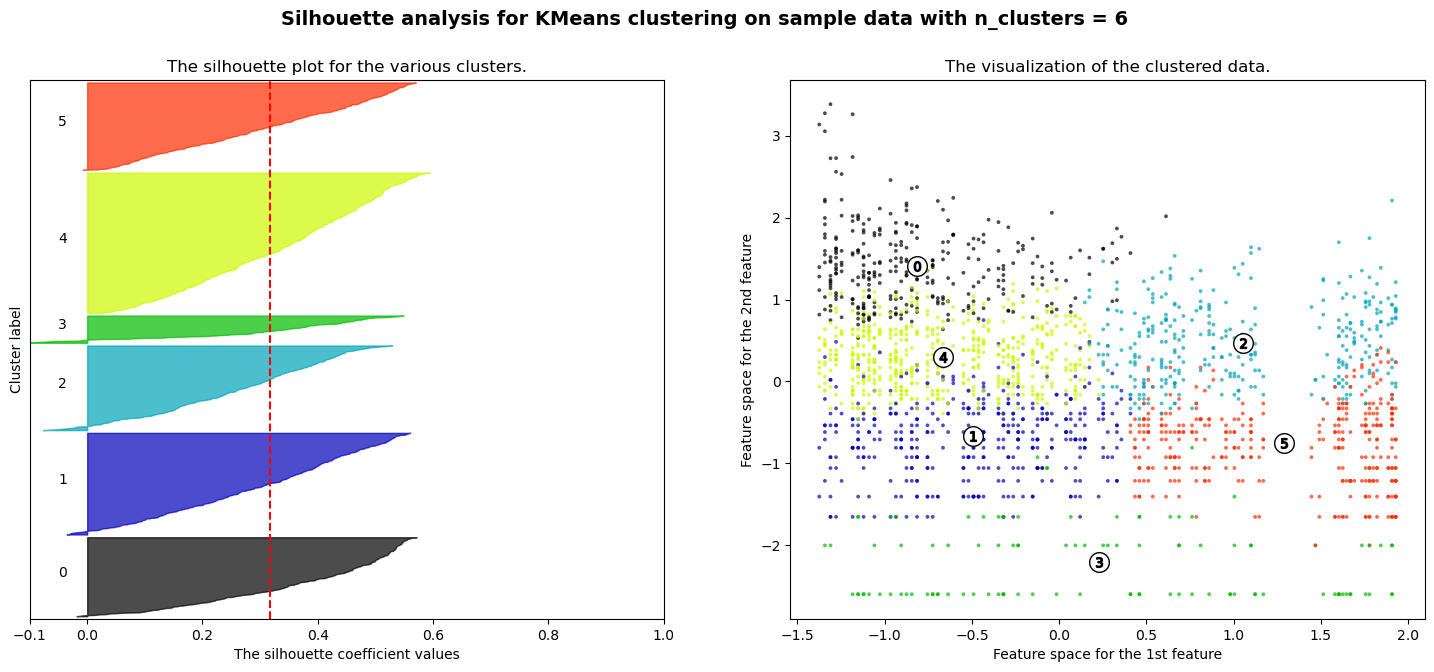

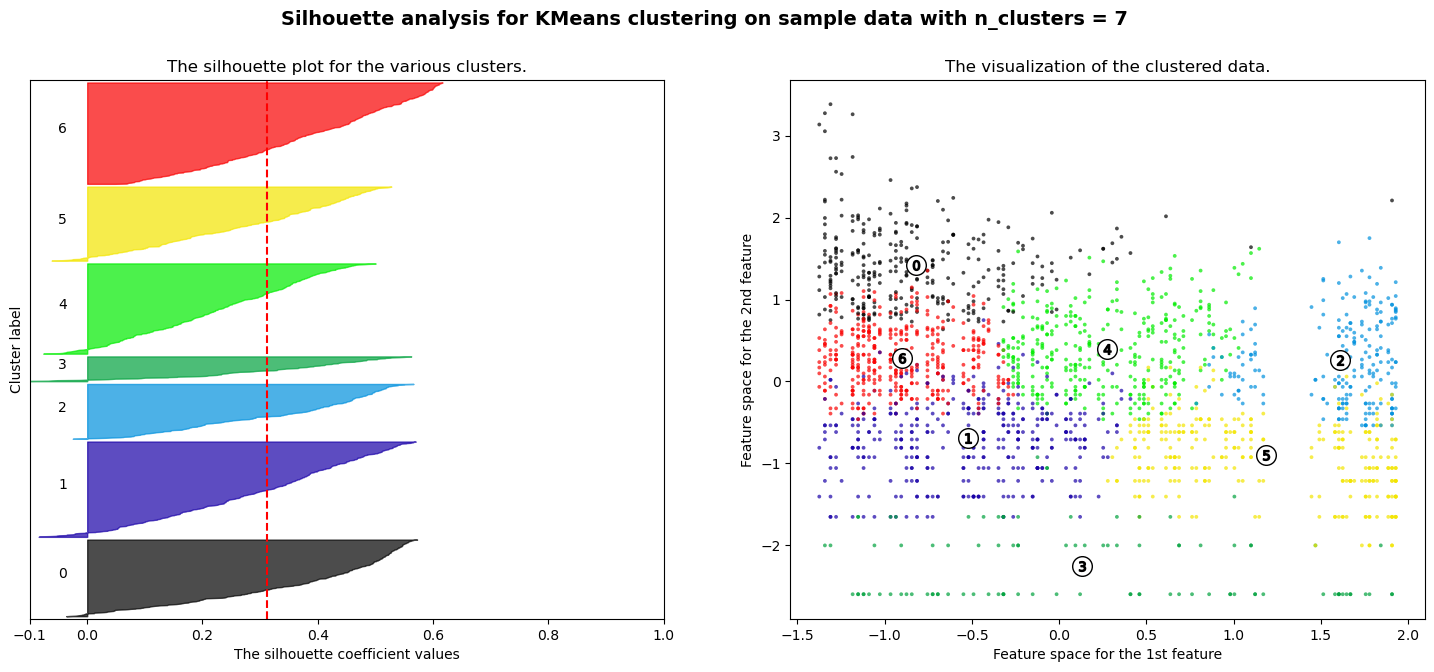

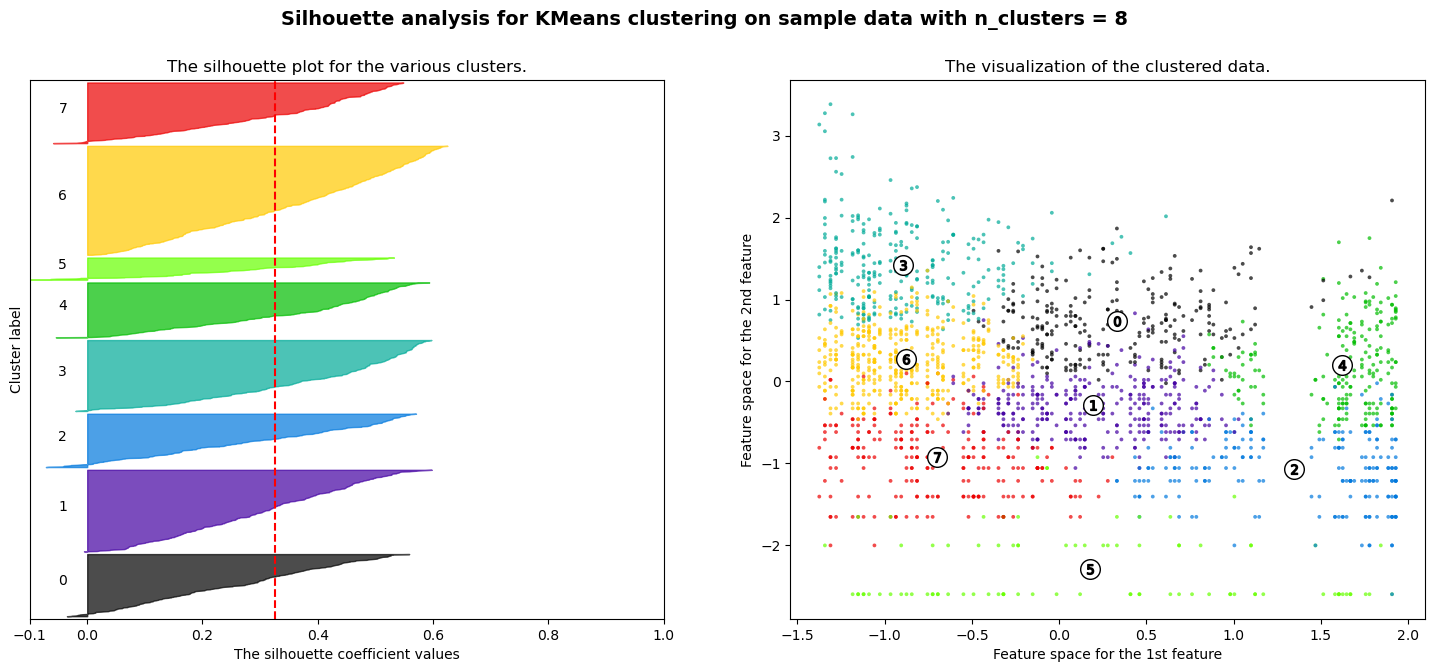

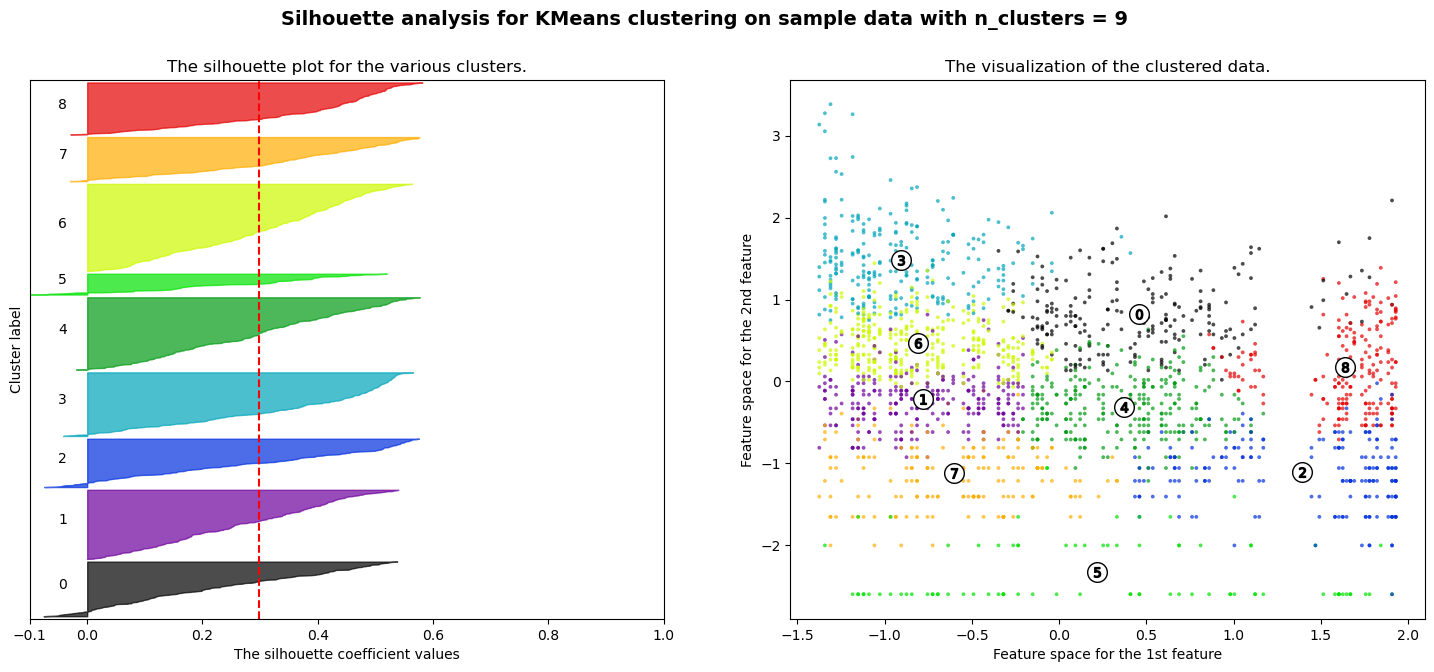

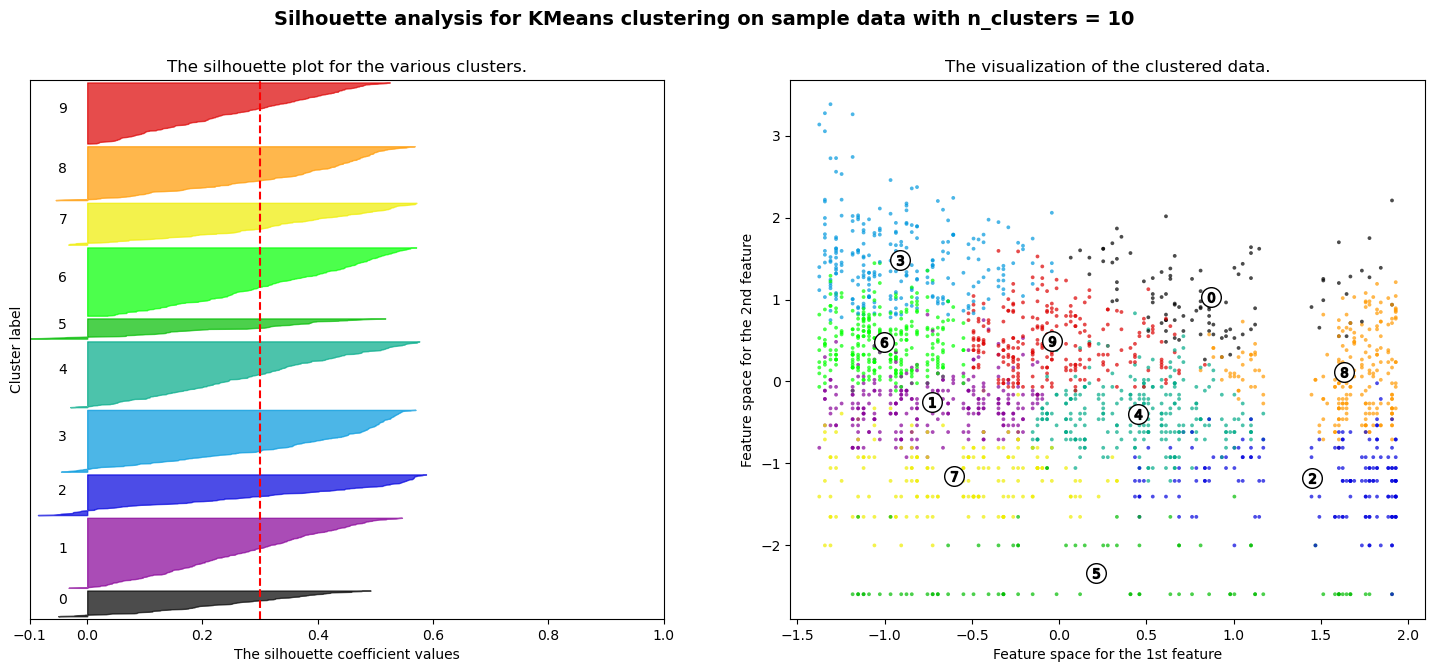

In [71]:
#applying silhouette method on RFM
range_n_clusters = [2,3,4,5,6,7,8,9,10]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this all lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=20)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is :", silhouette_avg)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) /n_clusters)
    ax2.scatter(X[:, 0], X[:, 1], marker='.', s=30, lw=0, alpha=0.7,
                c=colors, edgecolor='k')

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(centers[:, 0], centers[:, 1], marker='o',
                c="white", alpha=1, s=200, edgecolor='k')

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1,
                    s=50, edgecolor='k')

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")
    plt.suptitle(("Silhouette analysis for KMeans clustering on sample data "
                  "with n_clusters = %d" % n_clusters),
                 fontsize=14, fontweight='bold')

plt.show()

In [72]:
# KMeans with 2 clusters
kmeans = KMeans(n_clusters=2)
kmeans.fit(X)
y_kmeans= kmeans.predict(X)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


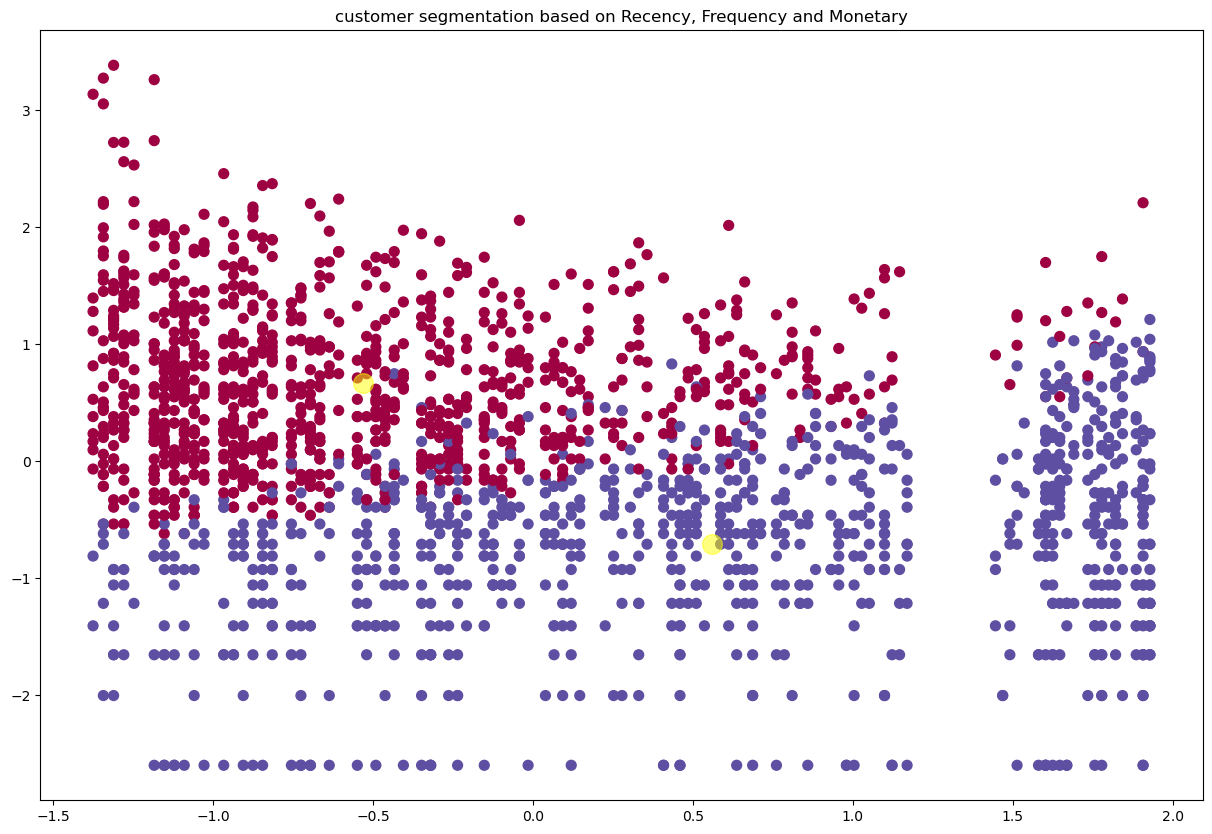

In [73]:
#plotting figure
plt.figure(figsize=(15,10))
plt.title('customer segmentation based on Recency, Frequency and Monetary')
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='Spectral')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='yellow', s=200, alpha=0.5);

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows wi

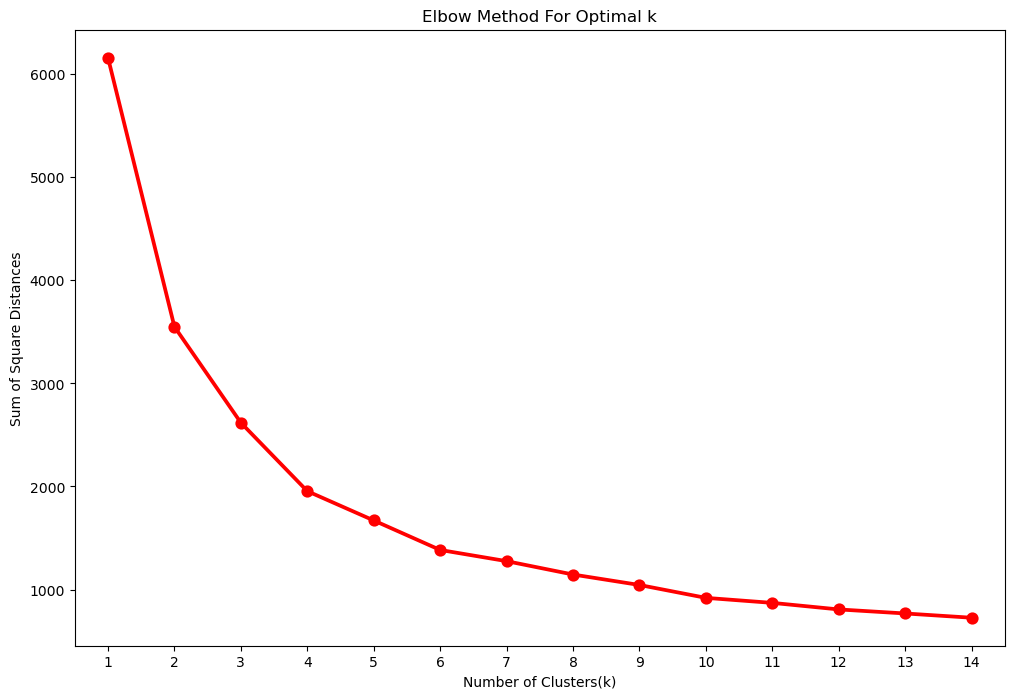

In [74]:
sum_of_sq_dist = {}
for k in range(1,15):
    km = KMeans(n_clusters= k, init= 'k-means++', max_iter= 1000)
    km = km.fit(X)
    sum_of_sq_dist[k] = km.inertia_
    
#Plot the graph for the sum of square distance values and Number of Clusters
plt.figure(figsize=(12,8))
sns.pointplot(x = list(sum_of_sq_dist.keys()), y = list(sum_of_sq_dist.values()),color='r')
plt.xlabel('Number of Clusters(k)')
plt.ylabel('Sum of Square Distances')
plt.title('Elbow Method For Optimal k')
plt.show()

In [75]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(retail_cleaned[['CustomerID', 'Quantity', 'TotalPrice']])
small_data = scaled_data[:80000]

In [76]:
distortions = []
K = range(2, 16)
for k in K:
    kmeans = MiniBatchKMeans(n_clusters = k, batch_size = 2560, random_state = 42)
    kmeans.fit(small_data)
    distortions.append(kmeans.inertia_)

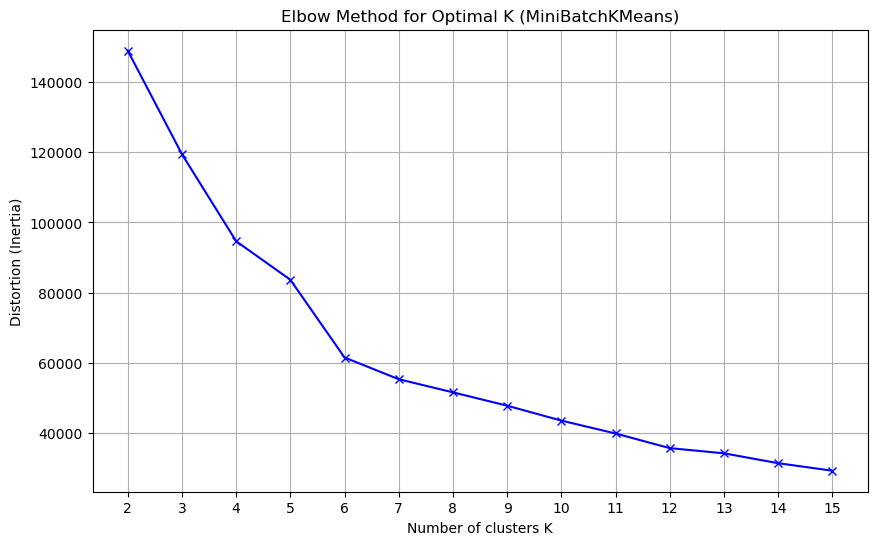

Optimal number of clusters based on elbow method: 6


In [77]:
plt.figure(figsize=(10, 6))
plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of clusters K')
plt.ylabel('Distortion (Inertia)')
plt.title('Elbow Method for Optimal K (MiniBatchKMeans)')
plt.xticks(K)
plt.grid()
plt.show()
kneedle = KneeLocator(K, distortions, curve='convex', direction='decreasing')
optimal_clusters = kneedle.elbow

print(f'Optimal number of clusters based on elbow method: {optimal_clusters}')

In [78]:
silhouette_scores = []

for k in range(2, 16):
    mbkmeans = MiniBatchKMeans(n_clusters = k, batch_size = 2560, random_state = 42)
    mbkmeans.fit(small_data)
    score = silhouette_score(small_data, mbkmeans.labels_)
    silhouette_scores.append(score)
    print(f"For n_clusters = {k}, the silhouette score is: {score}")

For n_clusters = 2, the silhouette score is: 0.35654208426480266
For n_clusters = 3, the silhouette score is: 0.33478422129093477
For n_clusters = 4, the silhouette score is: 0.31595700366195556
For n_clusters = 5, the silhouette score is: 0.31771293285651153
For n_clusters = 6, the silhouette score is: 0.36271911546664903
For n_clusters = 7, the silhouette score is: 0.3573391044848617
For n_clusters = 8, the silhouette score is: 0.32411534701681505
For n_clusters = 9, the silhouette score is: 0.32624926847039654
For n_clusters = 10, the silhouette score is: 0.334432716689671
For n_clusters = 11, the silhouette score is: 0.335101780757063
For n_clusters = 12, the silhouette score is: 0.34779633423979794
For n_clusters = 13, the silhouette score is: 0.32316973033332913
For n_clusters = 14, the silhouette score is: 0.32918647421273534
For n_clusters = 15, the silhouette score is: 0.3360305406944098


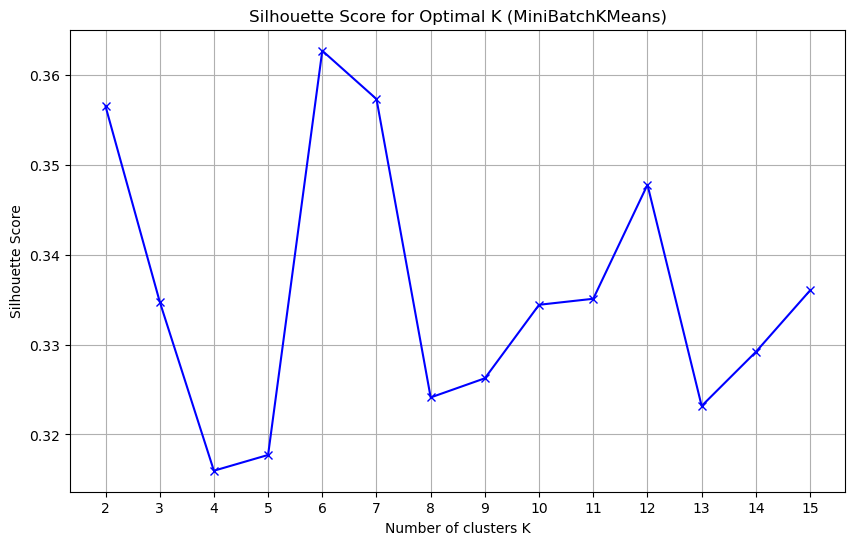

Optimal number of clusters: 6


In [79]:
plt.figure(figsize=(10, 6))
plt.plot(range(2, 16), silhouette_scores, 'bx-')
plt.xlabel('Number of clusters K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal K (MiniBatchKMeans)')
plt.xticks(range(2, 16))
plt.grid()
plt.show()
optimal_clusters = range(2, 16)[np.argmax(silhouette_scores)]
print(f'Optimal number of clusters: {optimal_clusters}')

In [80]:
batch_sizes = [2560, 3840, 5120, 6400, 7680, 8960, 10240]
inertia_values = []

In [81]:
for batch_size in batch_sizes:
    kmeans = MiniBatchKMeans(n_clusters = 6, batch_size = batch_size, random_state = 42)
    kmeans.fit(small_data)
    inertia_values.append(kmeans.inertia_)

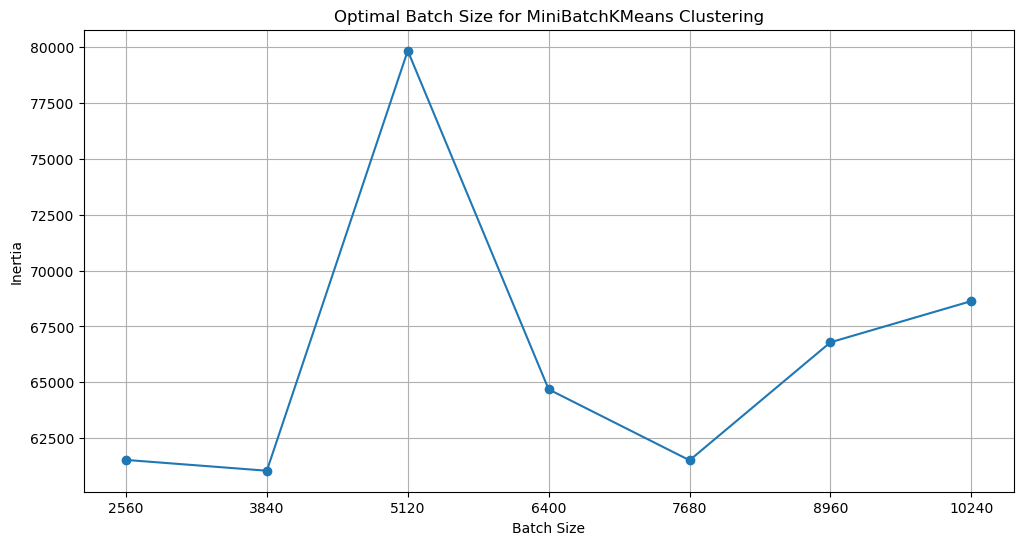

Optimal Batch Size: 3840, Inertia: 61044.71737101824


In [82]:
plt.figure(figsize=(12, 6))
plt.plot(batch_sizes, inertia_values, marker='o')

optimal_index = np.argmin(inertia_values)
optimal_batch_size = batch_sizes[optimal_index]
optimal_inertia = inertia_values[optimal_index]

plt.title('Optimal Batch Size for MiniBatchKMeans Clustering')
plt.xlabel('Batch Size')
plt.ylabel('Inertia')
plt.xticks(batch_sizes)
plt.grid()
    
plt.show()
print(f'Optimal Batch Size: {optimal_batch_size}, Inertia: {optimal_inertia}')

In [83]:
batch_sizes = [2560]
inertia_values = {batch_size: [] for batch_size in batch_sizes}

In [84]:
n_clusters_range = range(2, 16)

for n_cluster in n_clusters_range:
    for batch_size in batch_sizes:
        mbk = MiniBatchKMeans(n_clusters = n_cluster, batch_size = batch_size, random_state = 42)
        mbk.fit(small_data)  
        inertia = mbk.inertia_ 
        inertia_values[batch_size].append(inertia)

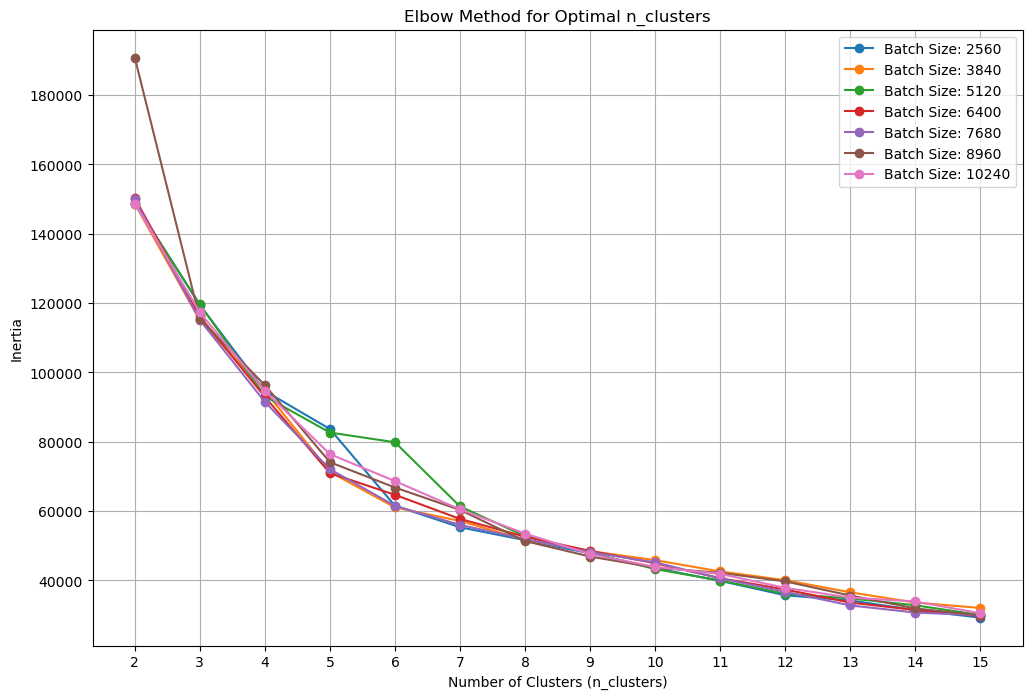

Optimal number of clusters based on elbow method: 6


In [85]:
plt.figure(figsize=(12, 8))
for batch_size, inertia in inertia_values.items():
    plt.plot(range(2, 16), inertia, marker='o', label=f'Batch Size: {batch_size}')

plt.title('Elbow Method for Optimal n_clusters')
plt.xlabel('Number of Clusters (n_clusters)')
plt.ylabel('Inertia')
plt.xticks(range(2, 16))  
plt.legend()
plt.grid()

plt.show()
kneedle = KneeLocator(K, distortions, curve='convex', direction='decreasing')
optimal_clusters = kneedle.elbow

print(f'Optimal number of clusters based on elbow method: {optimal_clusters}')

In [86]:
kmeans_model = MiniBatchKMeans(n_clusters = 6, batch_size = 3840)
kmeans_model.fit(scaled_data)

MiniBatchKMeans(batch_size=3840, n_clusters=6)

In [87]:
retail_cleaned['Cluster'] = kmeans_model.labels_

In [88]:
cluster_summary = retail_cleaned.groupby('Cluster')[['Quantity', 'UnitPrice', 'TotalPrice']].mean()
print(cluster_summary)

          Quantity  UnitPrice  TotalPrice
Cluster                                  
0         8.514120   2.320549   15.371774
1         2.484825   2.183471    4.292695
2        14.994644   2.489786   30.476860
3         8.188944   2.484565   15.828956
4         2.545263   2.191012    4.377929
5        23.819656   0.526015   12.452078


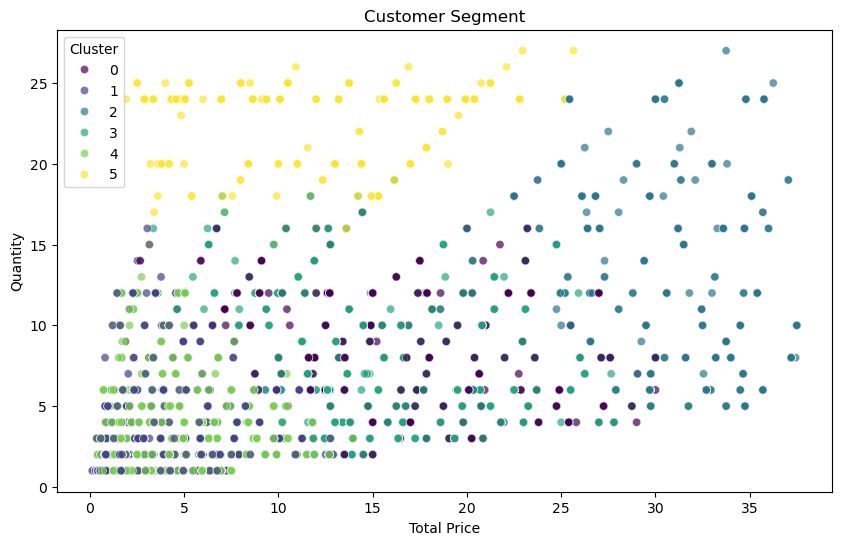

In [89]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data = retail_cleaned, x = 'TotalPrice', y = 'Quantity', hue = 'Cluster', palette='viridis', alpha=0.7)
plt.title('Customer Segment')
plt.xlabel('Total Price')
plt.ylabel('Quantity')
plt.legend(title='Cluster')
plt.show()   

In [ ]:
retail_cleaned.to_pickle('OnlineRetail_data.pkl')